In [56]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [57]:
train.shape

(3000888, 6)

In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [59]:
train.isnull().sum()


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [60]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [61]:
train.duplicated().sum()

np.int64(0)

In [62]:
print("Start date:", train["date"].min())
print("End date:", train["date"].max())

Start date: 2013-01-01
End date: 2017-08-15


In [63]:
train["date"] = pd.to_datetime(train["date"])

In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [65]:
train["date"].head()

0   2013-01-01
1   2013-01-01
2   2013-01-01
3   2013-01-01
4   2013-01-01
Name: date, dtype: datetime64[ns]

In [66]:
print("Number of stores:", train["store_nbr"].nunique())
print("Number of product families:", train["family"].nunique())

Number of stores: 54
Number of product families: 33


In [67]:
train["family"].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [68]:
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["day_of_week"] = train["date"].dt.dayofweek

In [69]:
train[["date", "year", "month", "day", "day_of_week"]].head(10)

,date,year,month,day,day_of_week
0,2013-01-01,2013,1,1,1
1,2013-01-01,2013,1,1,1
2,2013-01-01,2013,1,1,1
3,2013-01-01,2013,1,1,1
4,2013-01-01,2013,1,1,1
5,2013-01-01,2013,1,1,1
6,2013-01-01,2013,1,1,1
7,2013-01-01,2013,1,1,1
8,2013-01-01,2013,1,1,1
9,2013-01-01,2013,1,1,1


In [70]:
monthly_sales = train.groupby("month")["sales"].sum()

monthly_sales

month
1     9.444215e+07
2     8.063723e+07
3     9.722849e+07
4     9.066812e+07
5     9.439914e+07
6     9.451670e+07
7     1.033631e+08
8     8.347238e+07
9     7.747368e+07
10    8.008038e+07
11    8.033579e+07
12    9.702784e+07
Name: sales, dtype: float64

In [71]:
yearly_sales = train.groupby("year")["sales"].sum()

yearly_sales

year
2013    1.404190e+08
2014    2.094742e+08
2015    2.408801e+08
2016    2.886545e+08
2017    1.942171e+08
Name: sales, dtype: float64

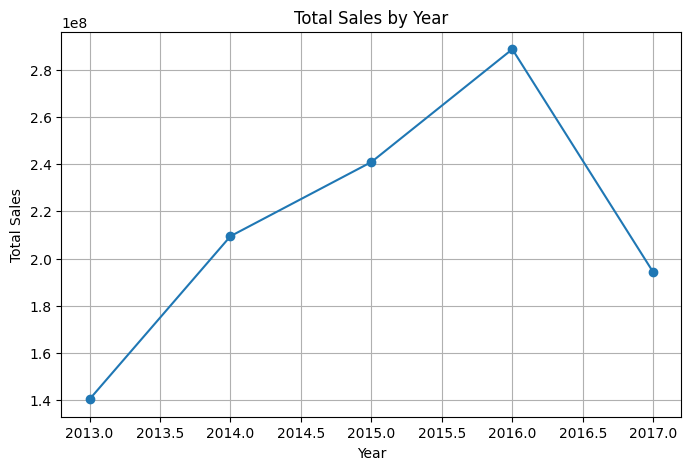

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

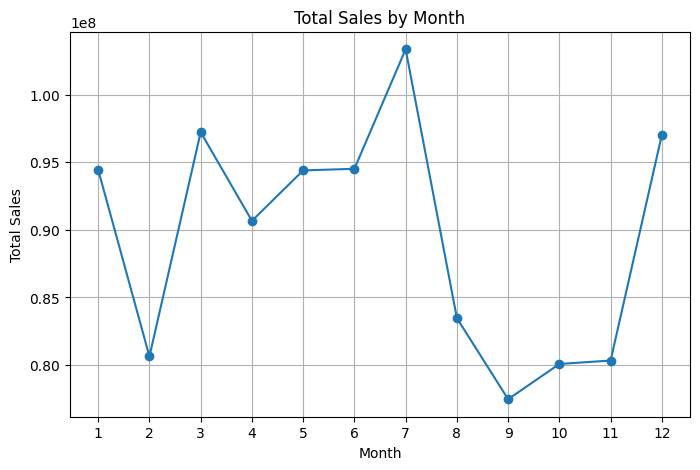

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [74]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [75]:
daily_sales.shape

(1684, 2)

In [76]:
full_dates = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(daily_sales["date"])

missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [77]:
len(missing_dates)

4

In [78]:
daily_sales = (
    daily_sales
    .set_index("date")
    .asfreq("D")
    .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [79]:
daily_sales["sales"] = daily_sales["sales"].fillna(0)

In [80]:
daily_sales.isnull().sum()

date     0
sales    0
dtype: int64

In [81]:
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day"] = daily_sales["date"].dt.day
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek

daily_sales.head()

,date,sales,year,month,day,day_of_week
0,2013-01-01,2511.618999,2013,1,1,1
1,2013-01-02,496092.417944,2013,1,2,2
2,2013-01-03,361461.231124,2013,1,3,3
3,2013-01-04,354459.677093,2013,1,4,4
4,2013-01-05,477350.121229,2013,1,5,5


In [82]:
split_index = int(len(daily_sales) * 0.8)

train_data = daily_sales.iloc[:split_index].copy()
test_data = daily_sales.iloc[split_index:].copy()

print("Training period:", train_data["date"].min(), "to", train_data["date"].max())
print("Testing period:", test_data["date"].min(), "to", test_data["date"].max())

Training period: 2013-01-01 00:00:00 to 2016-09-11 00:00:00
Testing period: 2016-09-12 00:00:00 to 2017-08-15 00:00:00


In [83]:
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training rows: 1350
Testing rows: 338


In [84]:
features = ["year", "month", "day", "day_of_week"]

X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

In [85]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1350, 4)
y_train: (1350,)
X_test: (338, 4)
y_test: (338,)


In [86]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 702902.7713253 ,  662630.27437706,  684904.59735242,
        573216.13359863,  697898.6939022 ,  911503.00186477,
       1001787.68061514,  752104.07687203,  686170.55522719,
        691314.88282987])

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 101874.18526744102
RMSE: 152294.34748418635
R²  : 0.3642850138030236


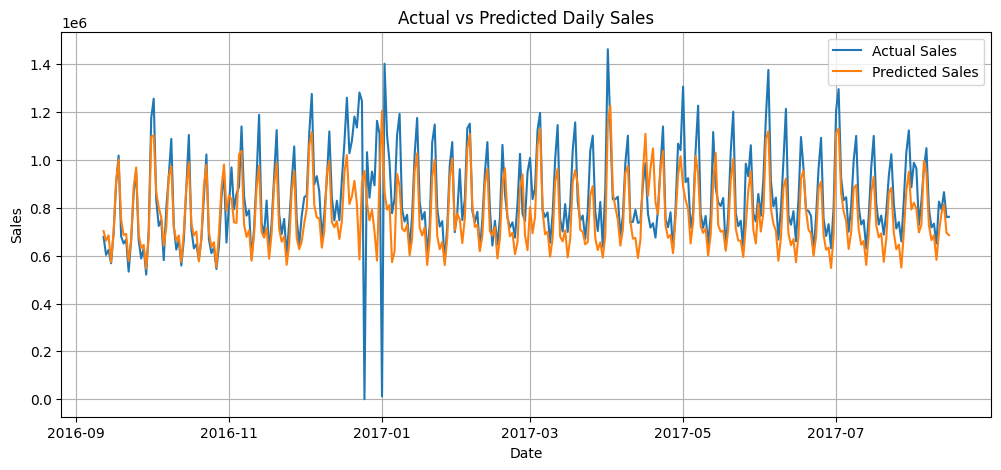

In [89]:
plt.figure(figsize=(12, 5))

plt.plot(test_data["date"], y_test.values, label="Actual Sales")
plt.plot(test_data["date"], y_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
daily_sales["sales_lag_1"] = daily_sales["sales"].shift(1)

daily_sales[["date", "sales", "sales_lag_1"]].head()

,date,sales,sales_lag_1
0,2013-01-01,2511.618999,NaN
1,2013-01-02,496092.417944,2511.618999
2,2013-01-03,361461.231124,496092.417944
3,2013-01-04,354459.677093,361461.231124
4,2013-01-05,477350.121229,354459.677093


In [91]:
daily_sales = daily_sales.dropna().reset_index(drop=True)

In [92]:
split_index = int(len(daily_sales) * 0.8)

train_data = daily_sales.iloc[:split_index].copy()
test_data = daily_sales.iloc[split_index:].copy()

print("Training period:", train_data["date"].min(), "to", train_data["date"].max())
print("Testing period:", test_data["date"].min(), "to", test_data["date"].max())

Training period: 2013-01-02 00:00:00 to 2016-09-11 00:00:00
Testing period: 2016-09-12 00:00:00 to 2017-08-15 00:00:00


In [93]:
features = ["year", "month", "day", "day_of_week", "sales_lag_1"]

X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1349, 5)
X_test: (338, 5)


In [94]:
from sklearn.ensemble import RandomForestRegressor

model_lag = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_lag.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
y_pred_lag = model_lag.predict(X_test)

y_pred_lag[:10]

array([ 692319.20480306,  647169.31511665,  668808.71230691,
        552039.5403027 ,  679517.2519529 ,  902477.51369142,
       1011872.39993888,  693933.41728249,  641697.21036389,
        678743.15932228])

In [96]:
mae_lag = mean_absolute_error(y_test, y_pred_lag)
rmse_lag = np.sqrt(mean_squared_error(y_test, y_pred_lag))
r2_lag = r2_score(y_test, y_pred_lag)

print("MAE :", mae_lag)
print("RMSE:", rmse_lag)
print("R²  :", r2_lag)

MAE : 86262.7816864906
RMSE: 143392.53263887408
R²  : 0.43642988997837706


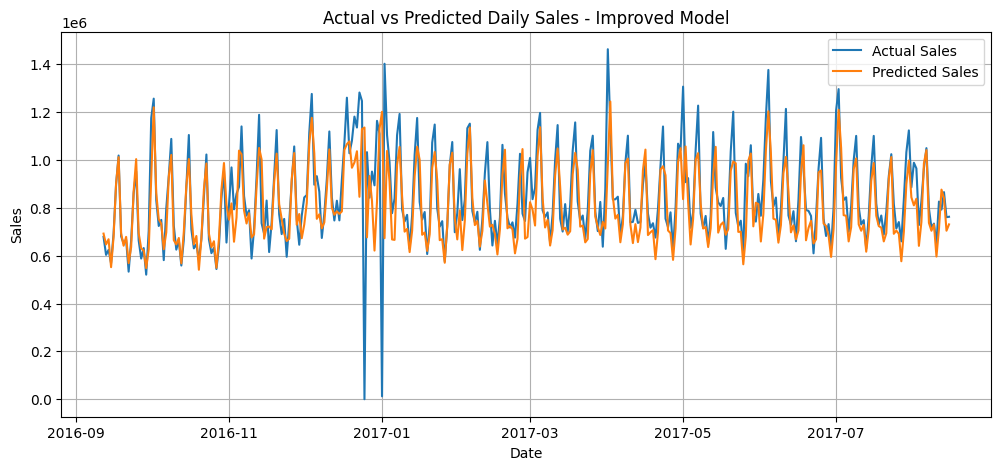

In [97]:
plt.figure(figsize=(12, 5))

plt.plot(test_data["date"], y_test.values, label="Actual Sales")
plt.plot(test_data["date"], y_pred_lag, label="Predicted Sales")

plt.title("Actual vs Predicted Daily Sales - Improved Model")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [98]:
feature_importance = pd.Series(
    model_lag.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

sales_lag_1    0.646044
day_of_week    0.227703
day            0.054113
year           0.041443
month          0.030697
dtype: float64

In [99]:
forecast = test_data[["date"]].copy()
forecast["actual_sales"] = y_test.values
forecast["predicted_sales"] = y_pred_lag

forecast.head()

,date,actual_sales,predicted_sales
1349,2016-09-12,678776.459126,692319.204803
1350,2016-09-13,603427.946974,647169.315117
1351,2016-09-14,624262.071976,668808.712307
1352,2016-09-15,568324.812986,552039.540303
1353,2016-09-16,691912.601466,679517.251953


In [100]:
forecast["error"] = forecast["actual_sales"] - forecast["predicted_sales"]

forecast["absolute_error"] = forecast["error"].abs()

forecast.head()

,date,actual_sales,predicted_sales,error,absolute_error
1349,2016-09-12,678776.459126,692319.204803,-13542.745677,13542.745677
1350,2016-09-13,603427.946974,647169.315117,-43741.368143,43741.368143
1351,2016-09-14,624262.071976,668808.712307,-44546.640331,44546.640331
1352,2016-09-15,568324.812986,552039.540303,16285.272683,16285.272683
1353,2016-09-16,691912.601466,679517.251953,12395.349513,12395.349513


In [101]:
forecast["absolute_error"].mean()

np.float64(86262.7816864906)

In [103]:
forecast["percentage_error"] = np.where(
    forecast["actual_sales"] != 0,
    (forecast["absolute_error"] / forecast["actual_sales"]) * 100,
    np.nan
)

forecast["percentage_error"].mean()

np.float64(38.07506229203267)

In [104]:
forecast.to_csv("../outputs/forecast_results.csv", index=False)

## Business Insights

- Historical sales show clear weekly seasonality, with certain days consistently performing better than others.
- Sales increased substantially from 2013 through 2016 before declining in the partial 2017 period.
- The previous day's sales (`sales_lag_1`) is the most important prediction feature.
- The model achieved an R² of approximately 0.44, indicating that it captures a meaningful portion of sales variation.
- The forecast can help businesses plan inventory, staffing, promotions, and short-term purchasing decisions.

# Business Interpretation

## What the Forecast Means

The forecasting model estimates daily sales based on historical sales patterns and time-based features. The results show that previous-day sales and day-of-week patterns are important factors in predicting future sales.

The model achieved an R² score of approximately 0.44, with an MAE of approximately 86,263 sales units. This indicates that the model captures meaningful sales patterns while still having room for improvement in predicting unusual sales spikes.

## How a Business Can Use the Forecast

The forecast can help a business:

- Plan inventory based on expected demand.
- Prepare staffing levels for higher and lower sales periods.
- Identify recurring weekly and seasonal sales patterns.
- Plan promotions around expected changes in demand.
- Support short-term purchasing and operational decisions.

The forecast should be used as a planning aid rather than an exact guarantee of future sales.